# 03 — Industry & Geography

Two more targeting dimensions beyond occupation and employer: **which industries** sponsor
MBA-relevant roles, and **where geographically**. Both cross-cut with wage, so a student can
answer "if I want a Financial Analyst role in Finance & Insurance, where does that pay best and
who's hiring the most?" in one pass.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_lca, load_perm, annual_wage  # noqa: E402
from mba_occupations import classify_mba_relevance  # noqa: E402
from employer_canonicalization import add_canonical_employer, build_canonical_map  # noqa: E402
from employer_brand_rollup import apply_brand_rollup  # noqa: E402
from naics_sectors import naics_sector  # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
FIG_DIR = Path.cwd().parent / "outputs" / "figures"

In [2]:
lca = load_lca()
perm = load_perm()

lca["MBA_TIER"] = classify_mba_relevance(lca["SOC_CODE"], lca["SOC_TITLE"])
perm["MBA_TIER"] = classify_mba_relevance(perm["PWD_SOC_CODE"], perm["PWD_SOC_TITLE"])

employer_mapping = build_canonical_map(lca["EMPLOYER_NAME"], perm["EMP_BUSINESS_NAME"])
lca = add_canonical_employer(lca, "EMPLOYER_NAME", "EMPLOYER_CANONICAL", mapping=employer_mapping)
perm = add_canonical_employer(perm, "EMP_BUSINESS_NAME", "EMPLOYER_CANONICAL", mapping=employer_mapping)
lca["EMPLOYER_CANONICAL"] = apply_brand_rollup(lca["EMPLOYER_CANONICAL"])
perm["EMPLOYER_CANONICAL"] = apply_brand_rollup(perm["EMPLOYER_CANONICAL"])

lca["NAICS_SECTOR"] = naics_sector(lca["NAICS_CODE"])
perm["NAICS_SECTOR"] = naics_sector(perm["EMP_NAICS"])

lca["ANNUAL_WAGE_FROM"] = annual_wage(lca["WAGE_RATE_OF_PAY_FROM"], lca["WAGE_UNIT_OF_PAY"])

lca_mba = lca[lca["MBA_TIER"] != "excluded"].copy()
perm_mba = perm[perm["MBA_TIER"] != "excluded"].copy()

## Which industries sponsor the most MBA-relevant roles?

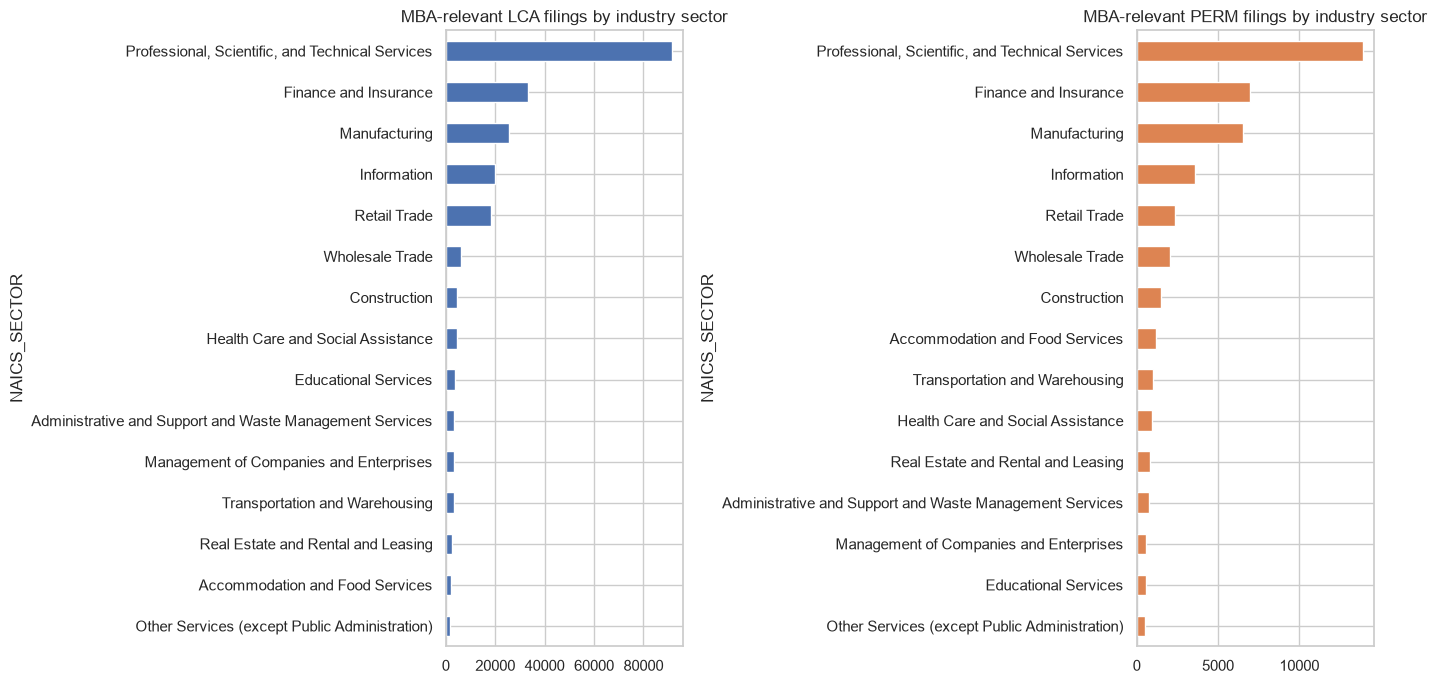

In [3]:
lca_sector_counts = lca_mba["NAICS_SECTOR"].value_counts()
perm_sector_counts = perm_mba["NAICS_SECTOR"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
lca_sector_counts.head(15).sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("MBA-relevant LCA filings by industry sector")
perm_sector_counts.head(15).sort_values().plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_title("MBA-relevant PERM filings by industry sector")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_mba_by_sector.png", dpi=150)
plt.show()

## Certification rate and wage by sector

In [4]:
def sector_scorecard(df, decided_statuses, denied_status, wage_col=None):
    decided = df[df["CASE_STATUS"].isin(decided_statuses)]
    cert_rate = decided.groupby("NAICS_SECTOR")["CASE_STATUS"].apply(lambda s: (s != denied_status).mean())
    volume = df.groupby("NAICS_SECTOR").size()
    out = pd.DataFrame({"filings": volume, "cert_rate": cert_rate})
    if wage_col:
        wage = df[(df[wage_col] > 20_000) & (df[wage_col] < 500_000)].groupby("NAICS_SECTOR")[wage_col].median()
        out["median_annual_wage"] = wage
    return out.sort_values("filings", ascending=False)


lca_sector_scorecard = sector_scorecard(
    lca_mba, ["Certified", "Certified - Withdrawn", "Denied"], "Denied", "ANNUAL_WAGE_FROM"
)
lca_sector_scorecard.head(15)

,filings,cert_rate,median_annual_wage
NAICS_SECTOR,,,
"Professional, Scientific, and Technical Services",91394,0.992842,120711.50
Finance and Insurance,33459,0.993850,143125.00
Manufacturing,25584,0.992027,136136.00
Information,19925,0.993602,164479.00
Retail Trade,18090,0.993814,140281.50
Wholesale Trade,6200,0.975305,87575.98
Construction,4580,0.965773,96424.84
Health Care and Social Assistance,4322,0.974852,88837.00
Educational Services,3798,0.988922,79040.00


In [5]:
perm_sector_scorecard = sector_scorecard(
    perm_mba, ["Certified", "Certified - Expired", "Denied"], "Denied"
)
perm_sector_scorecard.head(15)

,filings,cert_rate
NAICS_SECTOR,,
"Professional, Scientific, and Technical Services",13892,0.977259
Finance and Insurance,6952,0.987137
Manufacturing,6531,0.974072
Information,3575,0.989973
Retail Trade,2326,0.968764
Wholesale Trade,2029,0.957150
Construction,1508,0.955351
Accommodation and Food Services,1176,0.945193
Transportation and Warehousing,1011,0.957717


## Occupation x industry cross-tab

Coarse (2-digit) NAICS sectors miss the finance-vs-fintech-vs-consulting distinction that
matters to a finance/risk background — cross-tabbing occupation against sector at least shows
*which* sectors hire *which* MBA-relevant functions, so a student can spot e.g. "Financial Risk
Specialists cluster in Finance & Insurance, but also show up meaningfully in Professional
Services (consulting)."

In [6]:
cross_tab_lca = pd.crosstab(lca_mba["SOC_TITLE"], lca_mba["NAICS_SECTOR"])
top_occupations = lca_mba["SOC_TITLE"].value_counts().head(15).index
cross_tab_lca.loc[top_occupations].loc[:, cross_tab_lca.loc[top_occupations].sum().sort_values(ascending=False).head(8).index]

NAICS_SECTOR,"Professional, Scientific, and Technical Services",Finance and Insurance,Information,Manufacturing,Retail Trade,Wholesale Trade,Management of Companies and Enterprises,Administrative and Support and Waste Management Services
SOC_TITLE,,,,,,,,
Information Technology Project Managers,20508,3114,4175,2628,2190,336,245,403
Computer and Information Systems Managers,9190,2433,3797,2064,3020,301,288,280
Business Intelligence Analysts,8394,2671,2328,1628,3729,476,457,434
Accountants and Auditors,11834,1145,276,845,605,481,121,246
Financial and Investment Analysts,3282,9241,338,691,591,229,835,178
Operations Research Analysts,6127,1820,1281,1043,1330,408,154,122
Management Analysts,8883,725,620,559,242,306,168,186
Market Research Analysts and Marketing Specialists,3605,529,1511,1123,1169,1004,62,262
Project Management Specialists,2658,525,667,1096,807,129,62,108


## Geography: where should a student look, for a given industry/occupation?

State-level concentration and median wage, for MBA-relevant roles overall — filter this same
query down to a specific occupation/industry when using it interactively.

In [7]:
def geo_scorecard(df, state_col, wage_col=None):
    volume = df.groupby(state_col).size().rename("filings")
    out = volume.to_frame()
    if wage_col:
        wage = df[(df[wage_col] > 20_000) & (df[wage_col] < 500_000)].groupby(state_col)[wage_col].median()
        out["median_annual_wage"] = wage
    return out.sort_values("filings", ascending=False)


lca_geo = geo_scorecard(lca_mba, "WORKSITE_STATE", "ANNUAL_WAGE_FROM")
lca_geo.head(15)

,filings,median_annual_wage
WORKSITE_STATE,,
CA,46297,151200.0
NY,35489,142500.0
TX,28304,117262.0
WA,14696,151000.0
NJ,12628,121669.6
IL,10231,118186.0
FL,9125,105000.0
MA,8470,120000.0
GA,7960,115000.0


In [8]:
perm_geo = geo_scorecard(perm_mba, "PRIMARY_WORKSITE_STATE")
perm_geo.head(15)

,filings
PRIMARY_WORKSITE_STATE,
CA,10205
NY,6589
TX,4497
FL,3149
IL,2185
NJ,2084
MA,1705
WA,1620
GA,1571


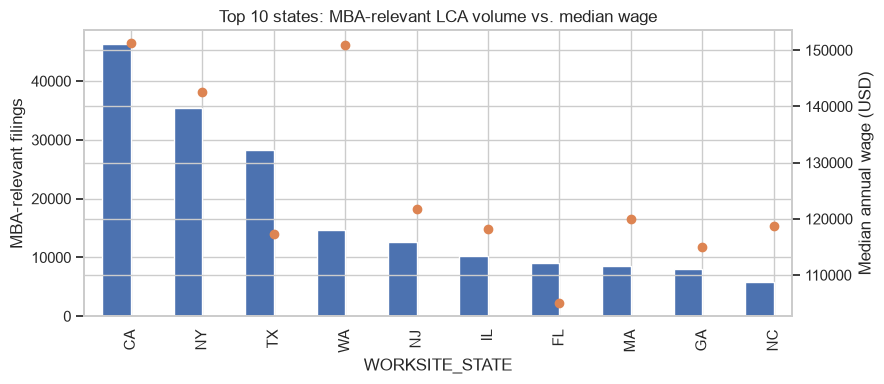

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
top10 = lca_geo.head(10)
ax2 = ax.twinx()
top10["filings"].plot.bar(ax=ax, color="#4C72B0", position=1, width=0.4)
top10["median_annual_wage"].plot(ax=ax2, color="#DD8452", marker="o", linestyle="none")
ax.set_ylabel("MBA-relevant filings")
ax2.set_ylabel("Median annual wage (USD)")
ax.set_title("Top 10 states: MBA-relevant LCA volume vs. median wage")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_geo_volume_vs_wage.png", dpi=150)
plt.show()

County-level detail is available (`WORKSITE_COUNTY` / `PRIMARY_WORKSITE_COUNTY`) for drilling
into specific metro areas once a state is picked — not expanded here to keep this notebook
readable, but ready for the interactive dashboard to use directly.

## Wage benchmarking: occupation x wage level x location

`PW_WAGE_LEVEL` (I-IV) is DOL's own classification of how much experience/responsibility a role
calls for — the closest available proxy to "years of experience needed" since no applicant-level
field exists. Level I/II roles are the entry-friendlier target for someone a few years out of
undergrad plus an MBA; Level III/IV skew toward more senior hires.

In [10]:
wage_level_by_occupation = (
    lca_mba.groupby(["SOC_TITLE", "PW_WAGE_LEVEL"]).size().unstack(fill_value=0)
)
wage_level_by_occupation["total"] = wage_level_by_occupation.sum(axis=1)
wage_level_by_occupation.sort_values("total", ascending=False).drop(columns="total").head(20)

PW_WAGE_LEVEL,I,II,III,IV
SOC_TITLE,,,,
Information Technology Project Managers,1253,10586,10056,11636
Business Intelligence Analysts,4305,8162,4134,2873
Computer and Information Systems Managers,1838,6634,4329,5048
Accountants and Auditors,4807,6603,2675,2539
Financial and Investment Analysts,3620,5667,3014,3551
Operations Research Analysts,2554,5003,3352,2719
Management Analysts,2273,4572,2538,3142
Market Research Analysts and Marketing Specialists,3168,3754,1990,1926
Project Management Specialists,1365,1984,1533,2103


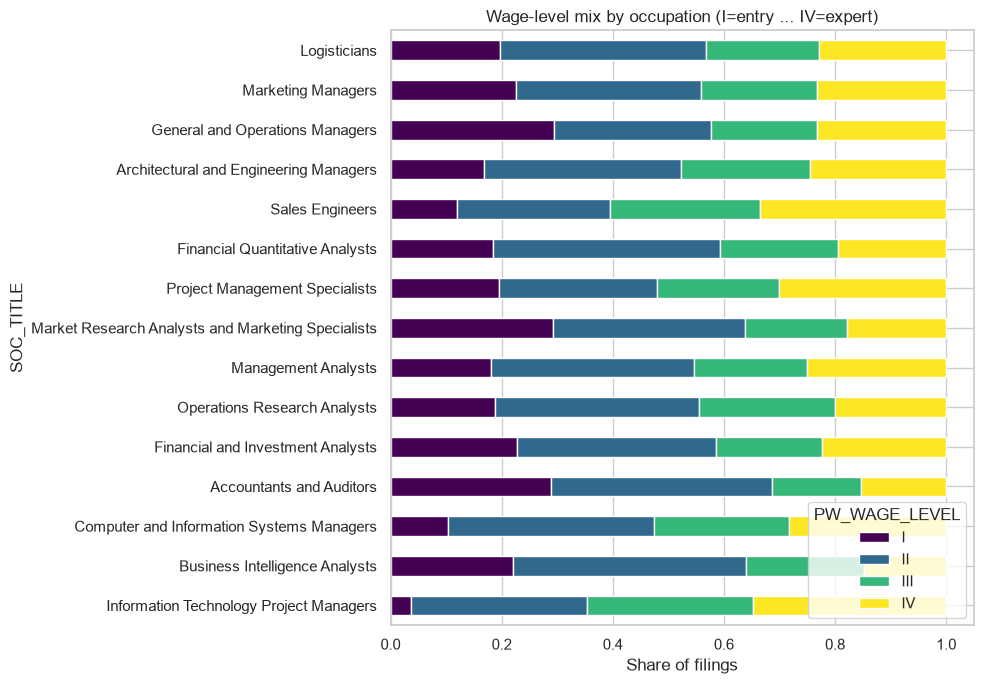

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
top15 = wage_level_by_occupation.sort_values("total", ascending=False).head(15).drop(columns="total")
top15_share = top15.div(top15.sum(axis=1), axis=0)
top15_share[["I", "II", "III", "IV"]].plot.barh(stacked=True, ax=ax, colormap="viridis")
ax.set_title("Wage-level mix by occupation (I=entry ... IV=expert)")
ax.set_xlabel("Share of filings")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_wage_level_mix.png", dpi=150)
plt.show()

## Save dashboard-ready aggregates

In [12]:
lca_sector_scorecard.reset_index().to_csv(PROCESSED_DIR / "lca_sector_scorecard.csv", index=False)
perm_sector_scorecard.reset_index().to_csv(PROCESSED_DIR / "perm_sector_scorecard.csv", index=False)
lca_geo.reset_index().to_csv(PROCESSED_DIR / "lca_state_scorecard.csv", index=False)
perm_geo.reset_index().to_csv(PROCESSED_DIR / "perm_state_scorecard.csv", index=False)
wage_level_by_occupation.reset_index().to_csv(PROCESSED_DIR / "lca_wage_level_by_occupation.csv", index=False)

print("Saved industry/geography aggregates to", PROCESSED_DIR)

Saved industry/geography aggregates to /Users/jaime/Local Documents/GitHub/h1b_analysis/data/processed


## Notes

- NAICS sector is only 2-digit here (`src/naics_sectors.py`) — coarse enough that "fintech"
  gets split across Finance & Insurance (52), Information (51, if the company is
  software-classified), and Professional Services (54, if consulting-adjacent). Employer-name
  keyword search (notebook 05) is the practical workaround for finer industry targeting.
- Wage-level mix is a solid proxy for seniority *expected by the role*, but doesn't tell us
  what a specific *employer's* bar is for a given level — two employers both filing "Level II
  Financial Analyst" may have very different actual hiring bars.